# 🚀 Alpha001 因子多股票回测（沪深300）

本 Notebook 演示基于 WorldQuant Alpha#001 因子的截面选股策略完整回测流程：

1. **数据准备** — 从本地 DuckDB 加载沪深300成分股日线 + 基准数据
2. **因子计算** — 用 `Alpha101Indicators` 批量计算面板 alpha001 值
3. **策略定义** — 截面排名选 Top-10，等权持仓，周频调仓
4. **运行回测** — 使用事件驱动 `BacktestEngine`
5. **绩效分析** — 夏普/最大回撤/Alpha/Beta 等完整指标
6. **结果可视化** — 净值曲线、回撤、持仓分布

## 1. 导入库与全局配置

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

# ── 项目模块 ───────────────────────────────────────────────────────────
from stockquant.data.universe import Pool, StockUniverse
from stockquant.research import AlphaResearcher           # 因子研究工具（新）
from stockquant.strategy import AlphaFactorStrategy       # 通用截面策略（新）
from stockquant.analysis.performance import PerformanceAnalyzer

# 显示设置
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

print("✅ 所有模块导入成功")
print("   AlphaResearcher  ← stockquant.research")
print("   AlphaFactorStrategy ← stockquant.strategy")

✅ 所有模块导入成功
   AlphaResearcher  ← stockquant.research
   AlphaFactorStrategy ← stockquant.strategy


## 2. 加载沪深300数据

使用 `StockUniverse` Builder，以 `Pool.CSI300` 为标的池，排除科创板/创业板/北交所后加载日线数据。

> **提示：** 如本地数据库为空，请先运行更新器：
> ```bash
> python -m stockquant.data.updater --mode hs300 --start-date 2022-01-01
> python -m stockquant.data.updater --mode benchmark --start-date 2022-01-01
> ```

In [2]:
# ── 回测参数 ──────────────────────────────────────────────
START_DATE = "2022-01-01"
END_DATE   = "2024-12-31"

# ── 加载沪深300标的池（排除科创板 / 创业板 / 北交所）──────
dataset = (
    StockUniverse()
    .scope(Pool.CSI300)
    .exclude(Pool.STAR, Pool.CHINEXT, Pool.BSE)
    .load(START_DATE, END_DATE, benchmark=Pool.CSI300)
)

stock_data   = dataset.stock_data      # dict[code, DataFrame]
benchmark_df = dataset.benchmark       # 沪深300指数日线
STOCK_CODES  = dataset.codes           # 实际加载到数据的代码列表
BENCHMARK    = dataset.benchmark_code  # "000300"

print(dataset.summary())
print(f"\n{'─'*50}")
print(f"实际加载: {len(STOCK_CODES)} 只股票 | 基准: {BENCHMARK}")
if dataset.missing_codes:
    print(f"⚠️  缺失数据 ({len(dataset.missing_codes)} 只): {dataset.missing_codes[:10]}...")

2026-03-08 06:14:02.656 | INFO     | stockquant.data.universe:_get_index_constituents:497 | 获取指数 000300 成分股
2026-03-08 06:14:08.580 | INFO     | stockquant.data.universe:_get_index_constituents:505 | 指数 000300 成分股: 280 只
2026-03-08 06:14:08.581 | INFO     | stockquant.data.universe:_apply_pool_exclude:453 | 排除 科创板: 移除 18 只
2026-03-08 06:14:08.582 | INFO     | stockquant.data.universe:_apply_pool_exclude:453 | 排除 创业板: 移除 32 只
2026-03-08 06:14:08.583 | INFO     | stockquant.data.universe:load:377 | 加载标的池: 沪深300（排除: 科创板, 创业板, 北交所） → 230 只
2026-03-08 06:14:08.601 | INFO     | stockquant.data.database:conn:46 | 已连接 DuckDB: /workspaces/stockQuant/stockquant/data/db/stockquant.duckdb
2026-03-08 06:14:08.613 | INFO     | stockquant.data.database:init_tables:110 | 数据库表初始化完成
2026-03-08 06:14:08.629 | INFO     | stockquant.data.data_manager:__init__:43 | 数据管理器初始化完成，主数据源: akshare
2026-03-08 06:14:09.803 | ERROR    | stockquant.data.source_akshare:get_daily_bars:83 | 获取 600930 日线数据失败: ('Connection 

📊 回测数据集摘要
   标的数量: 229 只（共请求 230 只）
   日期范围: 2022-01-01 ~ 2024-12-31
   基准指数: 000300（726 条）
   日线总条数: 164,404
   ⚠️ 缺失数据: ['600930']

──────────────────────────────────────────────────
实际加载: 229 只股票 | 基准: 000300
⚠️  缺失数据 (1 只): ['600930']...


## 3. 创建 AlphaResearcher 并计算 Alpha001 因子

`AlphaResearcher` 是从本 notebook 提取的公共框架类（位于 `stockquant/research/`），封装了：
- **因子计算**：延迟构建 Alpha101 引擎，带缓存避免重复计算
- **回测执行**：内置 `AlphaFactorStrategy` + `BacktestEngine`
- **性能分析**：`performance_summary()` / `metrics_table()`
- **可视化**：`plot_equity()` / `plot_monthly_heatmap()` / `plot_top_holdings()` / `compare_factors()`

$$\text{alpha001} = \text{rank}\!\left(\text{Ts\_ArgMax}\!\left(\text{SignedPower}(x,\,2),\;5\right)\right) - 0.5 \quad x = \begin{cases}\text{ts\_stddev}(\text{returns},\,20) & r_t < 0 \\ \text{close} & \text{otherwise}\end{cases}$$

In [3]:
# ── 策略参数 ──────────────────────────────────────────────
MAX_POSITIONS  = 10   # 最多持仓只数
REBALANCE_FREQ = 5    # 调仓频率（每 N 个交易日）
INITIAL_CAPITAL = 1_000_000.0

# ── 创建因子研究工具 ──────────────────────────────────────
researcher = AlphaResearcher(
    dataset,
    initial_capital = INITIAL_CAPITAL,
    max_positions   = MAX_POSITIONS,
    rebalance_freq  = REBALANCE_FREQ,
)

# ── 计算 Alpha001 因子面板（首次计算后自动缓存）────────────
alpha001_panel = researcher.get_alpha_panel(1)

print(f"\n✅ Alpha001 面板维度: {alpha001_panel.shape}  (日期 × 股票)")
print(f"   日期范围: {alpha001_panel.index[0].date()} ~ {alpha001_panel.index[-1].date()}")
print(f"   非空比例: {alpha001_panel.notna().mean().mean():.1%}")
alpha001_panel.tail(3).iloc[:, :5]

2026-03-08 06:14:13.318 | INFO     | stockquant.research.alpha_researcher:__init__:185 | AlphaResearcher 初始化: 229 只股票, max_pos=10, freq=5
2026-03-08 06:14:13.320 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:217 | 计算 Alpha001 面板...
2026-03-08 06:14:14.653 | INFO     | stockquant.research.alpha_researcher:alpha_engine:199 | 构建 Alpha101 面板引擎（首次访问）...
2026-03-08 06:14:15.288 | INFO     | stockquant.data.database:conn:46 | 已连接 DuckDB: /workspaces/stockQuant/stockquant/data/db/stockquant.duckdb
2026-03-08 06:14:15.362 | INFO     | stockquant.indicators.alpha101.alpha101:_auto_load_stock_info:418 | 已从 stock_info 加载行业数据: 85 个行业
2026-03-08 06:14:15.365 | INFO     | stockquant.indicators.alpha101.alpha101:_auto_load_stock_info:430 | 已从 stock_info 加载流通市值数据
2026-03-08 06:14:15.954 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:221 | Alpha001 计算完成，维度: (726, 229)



✅ Alpha001 面板维度: (726, 229)  (日期 × 股票)
   日期范围: 2022-01-04 ~ 2024-12-31
   非空比例: 98.4%


code,000001,000002,000063,000100,000157
date,,,,,
2024-12-27,-0.013216,-0.321586,0.211454,-0.321586,-0.321586
2024-12-30,0.325991,-0.350220,0.019824,-0.350220,-0.350220
2024-12-31,0.191630,-0.072687,-0.233480,0.191630,0.444934


## 4. 运行回测

`AlphaFactorStrategy`（位于 `stockquant/strategy/alpha_factor_strategy.py`）是从本 notebook 提取的通用截面选股策略，不再需要在 notebook 中重复定义：

| 参数 | 说明 |
|------|------|
| `alpha_panel` | 任意形如 `(日期 × 股票代码)` 的因子面板 |
| `max_positions` | 截面选 Top-N 只 |
| `rebalance_freq` | 每 N 个交易日调仓 |
| `ascending` | `False`=值越大越好（默认），`True`=值越小越好 |

`researcher.run_backtest(alpha_id=1)` 内部自动完成：因子获取 → 策略实例化 → BacktestEngine 配置 → 回测执行。

In [4]:
print("开始运行回测...")
result = researcher.run_backtest(alpha_id=1)   # AlphaFactorStrategy 已在框架中

print(f"\n{'═'*45}")
print(f"  回测结果摘要")
print(f"{'─'*45}")
for k, v in result.backtest_result.summary().items():
    print(f"  {k:<12}: {v}")
print(f"{'═'*45}")

开始运行回测...


2026-03-08 06:14:16.429 | INFO     | stockquant.backtest.engine:set_data:78 | 已加载 229 只标的，726 个交易日
2026-03-08 06:14:16.431 | INFO     | stockquant.research.alpha_researcher:run_backtest:308 | 运行回测: Alpha001  [2022-01-01 ~ 2024-12-31]
2026-03-08 06:14:16.432 | INFO     | stockquant.backtest.engine:run:104 | ====== 回测开始 ======
2026-03-08 06:14:16.434 | INFO     | stockquant.strategy.alpha_factor_strategy:initialize:62 | [Alpha001] 初始化完成 — max_pos=10, freq=5, target_pct=10.0%, ascending=False
2026-03-08 06:16:27.652 | INFO     | stockquant.backtest.engine:run:144 | ====== 回测结束 ======



═════════════════════════════════════════════
  回测结果摘要
─────────────────────────────────────────────
  初始资金        : 1,000,000
  最终市值        : 466,611
  总收益率        : -53.34%
  总交易次数       : 1981
═════════════════════════════════════════════


## 5. 绩效分析

## 6. 绩效分析

使用 `PerformanceAnalyzer` 计算完整绩效指标：

| 类别 | 指标 |
|------|------|
| 收益 | 总收益率、年化收益、Alpha、Beta |
| 风险 | 最大回撤、回撤持续时间、年化波动率、VaR(95%) |
| 风险调整 | 夏普比率 $\frac{\bar{R}-R_f}{\sigma}\sqrt{252}$、索提诺比率、卡玛比率 |
| 交易 | 总交易次数、佣金合计 |

In [5]:
report_df = researcher.performance_summary(result)
report_df.style.set_properties(**{"text-align": "left"}).set_caption("Alpha001 策略绩效报告")

2026-03-08 06:16:27.731 | INFO     | stockquant.analysis.performance:full_report:193 | 绩效报告:
2026-03-08 06:16:27.735 | INFO     | stockquant.analysis.performance:full_report:195 |   总收益率: -53.34%
2026-03-08 06:16:27.736 | INFO     | stockquant.analysis.performance:full_report:195 |   年化收益率: -23.25%
2026-03-08 06:16:27.737 | INFO     | stockquant.analysis.performance:full_report:195 |   Alpha: -15.80%
2026-03-08 06:16:27.737 | INFO     | stockquant.analysis.performance:full_report:195 |   Beta: 1.04
2026-03-08 06:16:27.738 | INFO     | stockquant.analysis.performance:full_report:195 |   最大回撤: 96.48%
2026-03-08 06:16:27.739 | INFO     | stockquant.analysis.performance:full_report:195 |   最大回撤天数: 722
2026-03-08 06:16:27.740 | INFO     | stockquant.analysis.performance:full_report:195 |   年化波动率: 1629.10%
2026-03-08 06:16:27.740 | INFO     | stockquant.analysis.performance:full_report:195 |   VaR(95%): -0.0851
2026-03-08 06:16:27.741 | INFO     | stockquant.analysis.performance:full_report:

,指标,值
0,总收益率,-53.34%
1,年化收益率,-23.25%
2,Alpha,-15.80%
3,Beta,1.04
4,最大回撤,96.48%
5,最大回撤天数,722
6,年化波动率,1629.10%
7,VaR(95%),-0.0851
8,夏普比率,-0.02
9,索提诺比率,-0.15


## 6. 可视化

以下使用 `AlphaResearcher` 内置的可视化方法，所有绘图逻辑已提取到框架，notebook 只需一行调用。

### 6.1 净值曲线 vs 沪深300基准

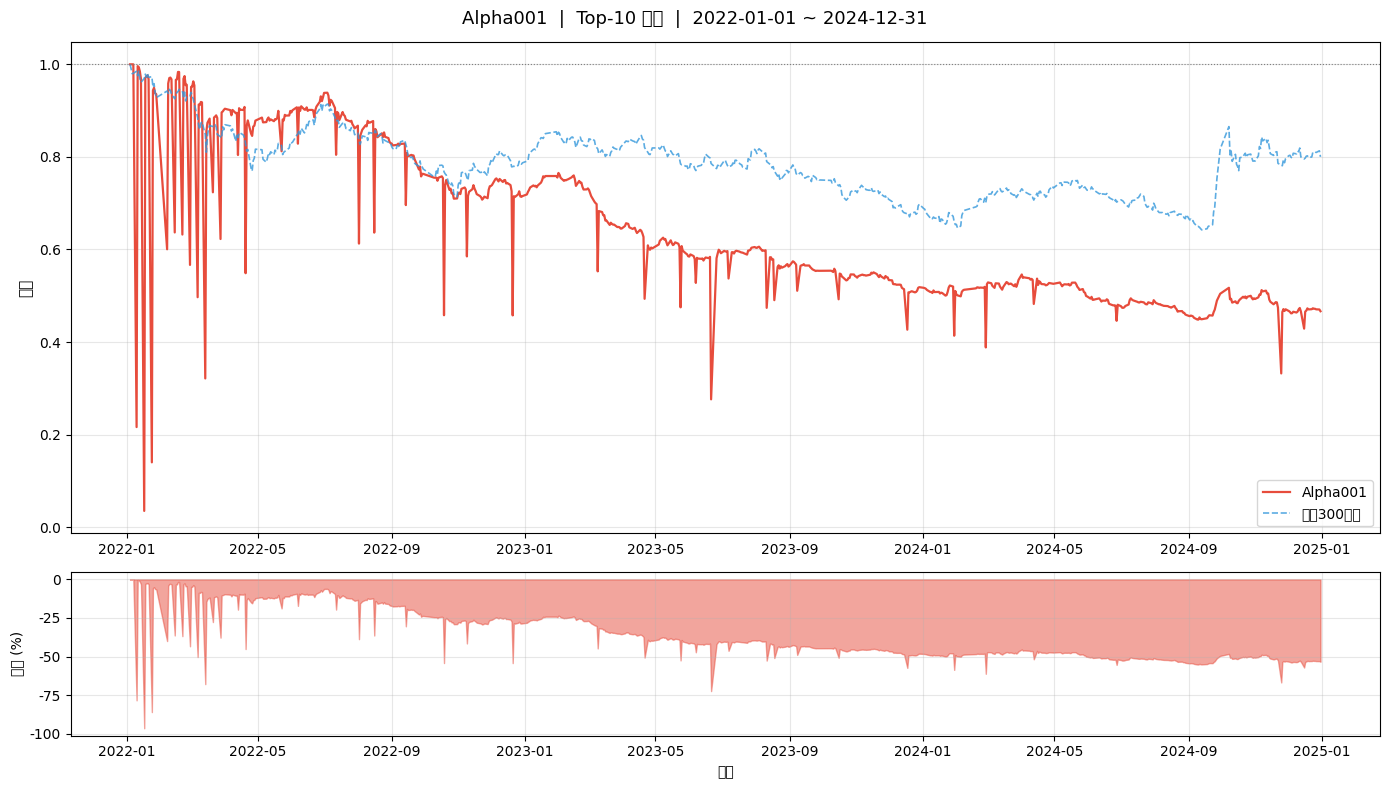

总收益率: -53.34% | 最大回撤: -96.48%


In [6]:
researcher.plot_equity(result)

### 6.2 月度收益热力图

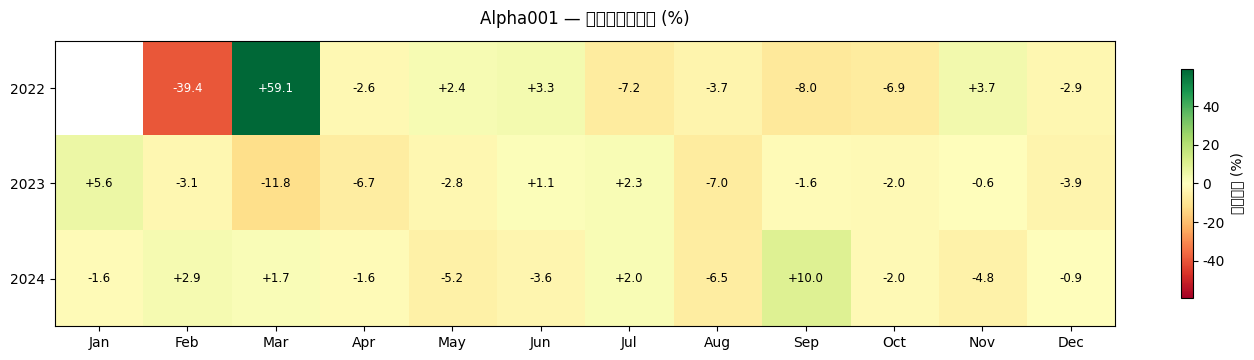

In [7]:
researcher.plot_monthly_heatmap(result)

### 6.3 最后调仓日 Top-10 持仓因子值

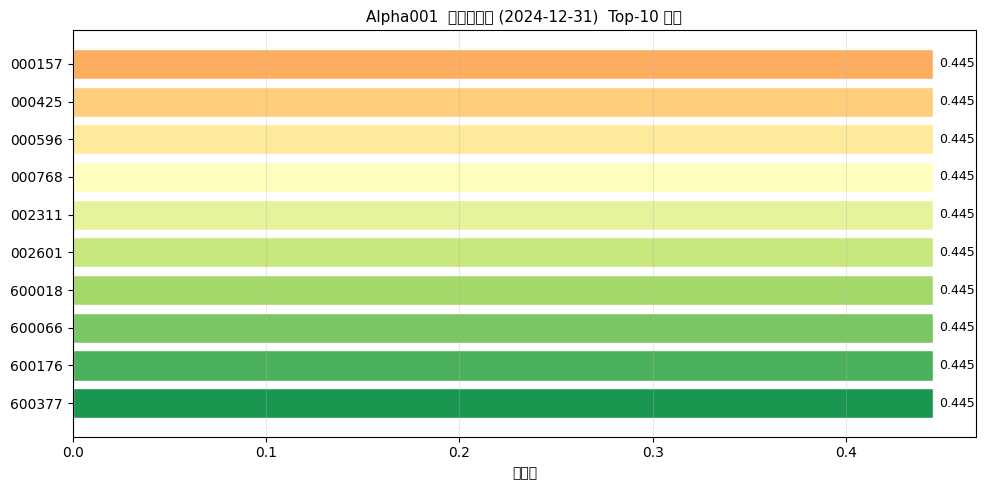

In [8]:
researcher.plot_top_holdings(result)

### 6.4 交易明细（最近 20 笔）

In [9]:
if not result.trade_log.empty:
    cols = [c for c in ["timestamp", "code", "direction", "filled_price",
                         "filled_quantity", "commission", "reason"]
            if c in result.trade_log.columns]
    display(result.trade_log[cols].tail(20).reset_index(drop=True))
    total_commission = result.trade_log.get("commission", pd.Series([0])).sum()
    print(f"\n总成交笔数: {len(result.trade_log)}  |  总佣金: ¥{total_commission:,.2f}")
else:
    print("⚠️  无交易记录，请检查数据或策略逻辑")

,code,direction,commission
0,600183,sell,39.845150
1,000975,buy,11.128212
2,000333,buy,8.500718
3,002142,buy,11.728410
4,000630,buy,9.061587
5,000338,buy,6.739953
6,000157,buy,9.445353
7,002142,sell,59.331100
8,000630,sell,45.389040
9,000975,sell,54.195142



总成交笔数: 1981  |  总佣金: ¥85,340.44
